W ramach projektu należy wytrenować model CNN do rozpoznawania i
klasyfikacji twarzy lub innych obiektów według własnego wyboru.

Zbiór danych
musi zawierać co najmniej 100 obrazków dla każdej klasy,
gdzie minimalna liczba klas wynosi 3. Należy skorzystać z augmentacji zbiorów.

Framework
Dowolny według własnych preferencji.

Kamerka
Po wytrenowaniu modelu trzeba połączyć go z biblioteką OpenCV w celu rozpoznawania obiektów za pomocą kamerki.

In [1]:
import cv2
#pip install numpy matplotlib tensorflow scikit-learn opencv-python seaborn
# import bibliotek:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from keras.models import Sequential, load_model
from keras.layers import (          #warstwy do budowy sieci
    Input,
    Conv2D,
    BatchNormalization,
    Activation,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Flatten,
    Dense,
    Dropout
)
from keras.optimizers import Adam       #optymalizator Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# import danych z folderu assets
img_size = (128,128)
batch_size = 32

train_path = "AssetsBetter/train"
test_path = "AssetsBetter/test"

#augmentacja i normalizacja
train_datagen = ImageDataGenerator(
  rescale=1./255,
  rotation_range=30,
  width_shift_range=0.1,
  height_shift_range=0.1,
  horizontal_flip=False,
  # vertical_flip=True,
  brightness_range=(0.8, 1.2),
  zoom_range=0.2,
)

#normalizacja dla testow
test_datagen = ImageDataGenerator(
  rescale=1./255
)

#generator dla trenowania
train_generator = train_datagen.flow_from_directory(
  train_path,
  target_size=img_size,
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True
)

#generator dla testu
test_generator = test_datagen.flow_from_directory(
  test_path,
  target_size=img_size,
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=False
)
print(f"train: {train_generator.class_indices}")
print(f"test: {test_generator.class_indices}")

Found 1932 images belonging to 5 classes.
Found 184 images belonging to 5 classes.
train: {'kaczka_biala': 0, 'kaczka_czerwona': 1, 'kaczka_fancy': 2, 'kaczka_rozowa': 3, 'kaczka_zolta': 4}
test: {'kaczka_biala': 0, 'kaczka_czerwona': 1, 'kaczka_fancy': 2, 'kaczka_rozowa': 3, 'kaczka_zolta': 4}


In [3]:
#wstepne przetwarzanie danych
input_shape = (128,128,3)

In [4]:
#model:
# model = Sequential(
#     [
#         Input(shape=input_shape),
#
#         #blok 1
#         Conv2D(32, 3, padding='same'),
#         BatchNormalization(),
#         Activation('relu'),
#         MaxPooling2D((2,2)),
#         Dropout(0.1),
#
#         #blok 2
#         Conv2D(64, 3, padding='same'),
#         BatchNormalization(),
#         Activation('relu'),
#         MaxPooling2D((2,2)),
#         Dropout(0.2),
#
#         #blok 3
#         Conv2D(128, 3, padding='same'),
#         BatchNormalization(),
#         Activation('relu'),
#         MaxPooling2D((2,2)),
#         Dropout(0.3),
#
#         #klasyfikacja
#         GlobalAveragePooling2D(),
#         # Flatten(),#nei flatten bo uczy sie na pamiec
#
#         Dense(128),
#         BatchNormalization(),
#         Activation('relu'),
#         Dropout(0.3),
#
#         Dense(5, activation = 'softmax')
#     ]
# )

model = Sequential([
    Input(shape=input_shape),

    Conv2D(32, 3,activation='relu',padding='same'),
    MaxPooling2D(),

    Conv2D(64, 3,activation='relu', padding='same'),
    MaxPooling2D(),

    Conv2D(128, 3,activation='relu', padding='same'),
    MaxPooling2D(),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(5, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',            #funkcja straty categorical_clossentropy -> stosowana przy klasyfikacji wieloklasowej,
                                                #ektykietach typu one-hot i przy ostatniej warstwie softmax
    metrics=['accuracy']
)

# Wyświetlenie podsumowania modelu
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#trenowanie modelu
es = EarlyStopping(           #zatrzymuje kiedy dokaldnosc walidacji nie poprawia sie przez <patience> epok
    monitor='val_loss',       # metryka, którą obserwujemy (np. val_loss, val_accuracy)
    patience=10,               # liczba epok bez poprawy, po których zatrzymujemy trening
    min_delta=1e-5,           # minimalna wymagana zmiana, by uznać, że jest „poprawa”
    mode='min',               # 'min' jeśli monitorujemy straty, 'max' jeśli dokładność
    restore_best_weights=True
)
rlp = ReduceLROnPlateau(    #jezeli uczenie nie poprawilo sie przez ostatnie 6 epok,
                            # mdoel wraca do ostatniego minimum lokalnego
    monitor='val_loss',   # metryka do obserwacji
    factor=0.5,           # ile razy zmniejszyć LR (tu: o połowę)
    patience=6,           # liczba epok bez poprawy przed zmniejszeniem LR, rlp.patience < es.patience
    min_delta=1e-5,       # próg czułości jak wyżej
    min_lr=1e-5,          # dolna granica learning rate
    mode='min',           # 'min' dla strat, 'max' dla dokładności
)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=50,
    callbacks= [es,rlp]
)

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 37s 582ms/step - accuracy: 0.2195 - loss: 1.6044 - val_accuracy: 0.1957 - val_loss: 1.5967 - learning_rate: 1.0000e-04
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 32s 522ms/step - accuracy: 0.3416 - loss: 1.5726 - val_accuracy: 0.3967 - val_loss: 1.5337 - learning_rate: 1.0000e-04
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 31s 509ms/step - accuracy: 0.5290 - loss: 1.4422 - val_accuracy: 0.6196 - val_loss: 1.3091 - learning_rate: 1.0000e-04
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 477ms/step - accuracy: 0.6108 - loss: 1.1769 - val_accuracy: 0.7609 - val_loss: 1.0282 - learning_rate: 1.0000e-04
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 28s 453ms/step - accuracy: 0.6765 - loss: 0.9444 - val_accuracy: 0.7826 - val_loss: 0.7961 - learning_rate: 1.0000e-04
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 27s 445ms/step - accuracy: 0.7257 - loss: 0.7880 - val_accuracy: 0.7554 - val_loss: 0.6631 - learning_rate: 1.0000e-04
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 28s 453ms/step - acc

In [5]:
#ewaluacja modelu
# model.save("kaczkiRecognitionModelCNN.keras")

model = load_model("kaczkiRecognitionModelCNN.keras")

test_generator.reset()

loss,accuracy = model.evaluate(test_generator)
print(f"loss: {loss}")
print(f"accuracy: {accuracy}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - accuracy: 0.9837 - loss: 0.0622
loss: 0.06224225461483002
accuracy: 0.9836956262588501


61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 298ms/step


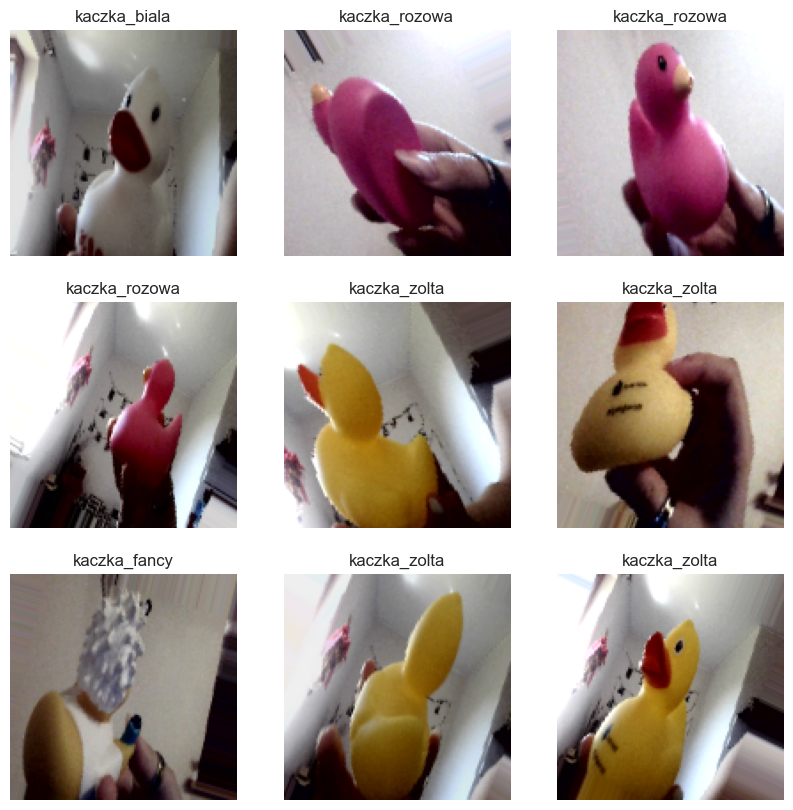

61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 239ms/step


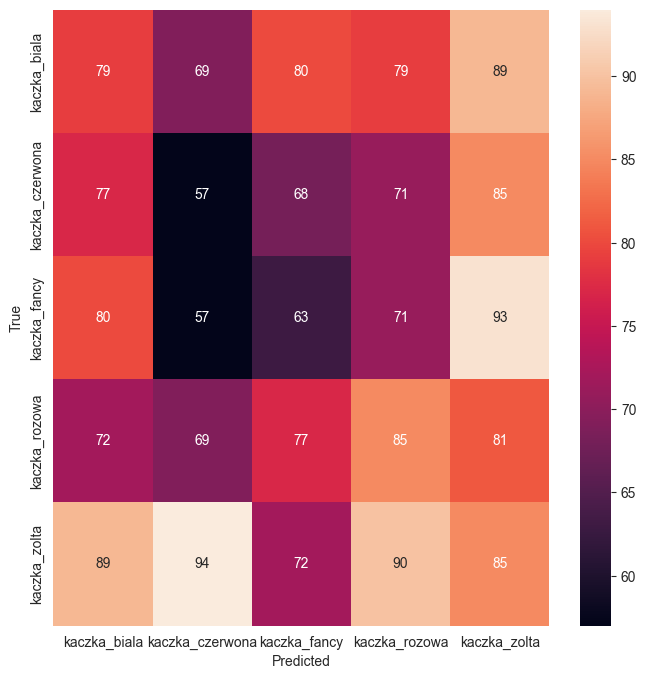

In [6]:
#predykcja
train_generator.reset()

pred_probs = model.predict(train_generator)

pred_labels = np.argmax(pred_probs, axis=1)

true_labels = train_generator.classes

class_names = list(train_generator.class_indices.keys())

images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis('off')

plt.show()


#confusion matrix
train_generator.reset()

pred = model.predict(train_generator)
pred_classes = np.argmax(pred, axis=1)

cm = confusion_matrix(true_labels, pred_classes)

plt.figure(figsize=(8,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step


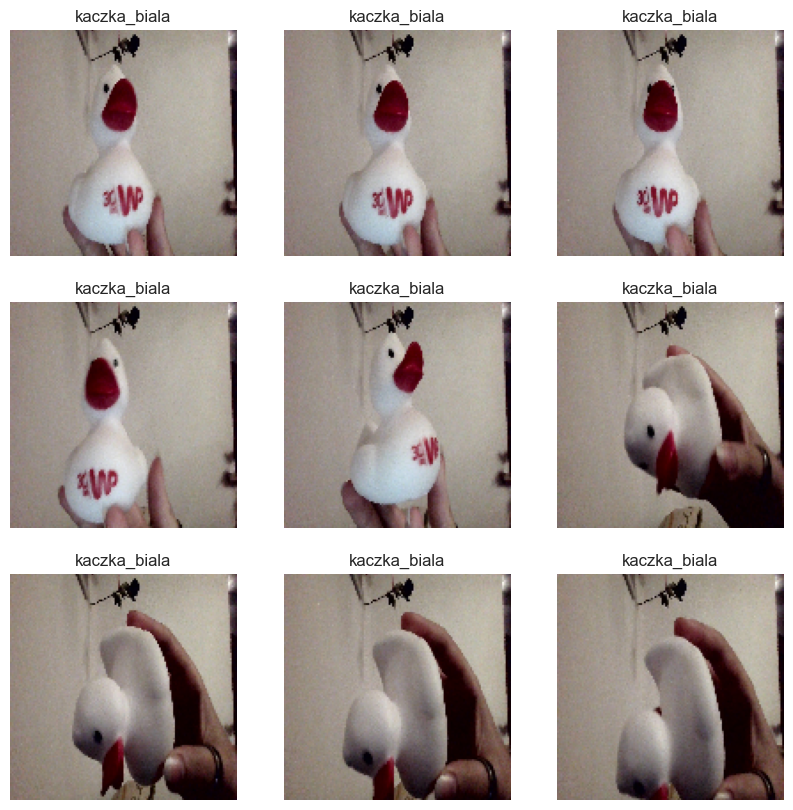

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step


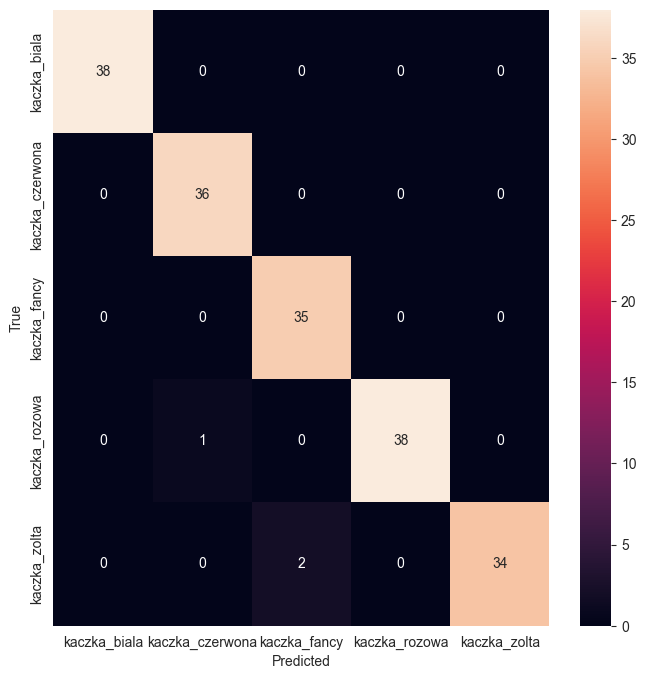

In [7]:
#predykcja i confusion matrix
pred_probs = model.predict(test_generator)

pred_labels = np.argmax(pred_probs, axis=1)

true_labels = test_generator.classes

class_names = list(test_generator.class_indices.keys())

images, labels = next(test_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis('off')

plt.show()

# CONFUSION MATRIX

test_generator.reset()

pred_probs = model.predict(test_generator)

pred_classes = np.argmax(pred_probs, axis=1)

true_labels = test_generator.classes

cm = confusion_matrix(true_labels, pred_classes)

plt.figure(figsize=(8,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()


In [9]:
#podlaczenie kamery
classes = list(train_generator.class_indices.keys())

cap = cv2.VideoCapture(0)
img_size = 128

while True:
    ret, frame = cap.read()

    if not ret:
        break

    #odbicie lustrzane
    frame = cv2.flip(frame,1)

    img = cv2.resize(frame,(img_size,img_size))
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img = img.astype('float32')/255.0 #normalizacja
    img = np.expand_dims(img, axis=0)

    #predykcja kaczki
    precision = model.predict(img, verbose=0)
    confidence = np.max(precision)
    if confidence >= 0.5:
        label = classes[np.argmax(precision)]
    else:
        label = "Nie rozpoznano"

    #tekst na ekranie
    text = f"{label}: {confidence*100:.2f}%"

    cv2.putText(
        frame,
        text,
        (20,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255,0,0),
        2
    )

    #pokazanie obrazu
    cv2.imshow('ObjectsRecognitionCNN',frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()